In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [67]:
def sho_expects(del_t,period_number, eta, k, gamma, x0, p0):
    

    #We will multiply all values by scale values at the end to get real values 
    #Real params 
    w1_real = 50000 * 2*np.pi  #rad/s
    m_bead = 4.8e-18 #kg
    hbar = 1.054e-34 #Js
     
    x = x0
    p = p0
    exp_x, exp_p,exp_x_sq,exp_p_sq = [x], [p], [0],[0]
    
    
    #Define scale values such that w1, m are 1
    w1_scale = w1_real
    m_scale = m_bead
    
    #Define scale factors for position and momentum 
    x_scale = np.sqrt(hbar/(m_scale*w1_scale))
    p_scale = np.sqrt(hbar*m_scale*w1_scale)
    t_scale = 1/w1_scale
    

    w1 = w1_real/w1_scale
    m = m_bead/m_scale
    
    epsilon = -2*gamma/w1
    
    T = (2*np.pi)/w1
    t = period_number*T
    
    steps = int(t/del_t)
    t_arr = np.linspace(0, t, steps)
    t_per_arr = t_arr/T
    
    
    
    var_x = 1/(2*m*w1)
    var_p = m*w1/2
    cov_xp = 0

    
    w_sq = w1**2*(1 - 2*epsilon)
    phi = np.arctan2(p, x)
    phi_p = np.pi/2 - 2*phi
    r = np.sqrt((x**2+p**2)/2)
    t_op = np.log(1+ 4*r**2)/(4*gamma)
    
    w_sq_list = [w_sq]
    phi_p_list = [phi_p]
    t_op_list = [t_op]
    
    for i in range(steps-1):
        del_W = np.random.normal(loc=0.0, scale=np.sqrt(del_t), size=None)

        
        x += (1/m*p*del_t) 
        p += (-m* w_sq*x*del_t)
        
        var_x += (2/m*cov_xp) * del_t
        var_p += (-2*m*w_sq*cov_xp) * del_t
        cov_xp += (1/m*var_p - m*w_sq*var_x) *del_t
        
        x_sq = var_x + x**2
        p_sq = var_p + p**2 
        
       
        exp_x.append(x)
        exp_p.append(p)
        
        exp_x_sq.append(x_sq)
        exp_p_sq.append(p_sq)
        
        
        if t_arr[i] > t_op:
            phi = np.arctan2(p, x)
            phi_p = np.pi/2 - 2*phi
            r = np.sqrt((x**2+p**2)/2)
            
            
            t_op = t_arr[i] + np.log(1+ 4*r**2)/(4*gamma) 
            t_op_list.append(t_op)
            
            phi_p_list.append(phi_p)
            
        w_sq = w1**2*(1 - 2*epsilon*np.cos(2*w1*t_arr[i]+phi_p))
        w_sq_list.append(w_sq)
    
    t_real_arr = t_arr *t_scale
    t_op_real = np.array(t_op_list)*t_scale
    exp_x_real  = np.array(exp_x) * x_scale
    exp_p_real  = np.array(exp_p) * p_scale
    exp_x_sq_real = np.array(exp_x_sq) * x_scale**2
    exp_p_sq_real = np.array(exp_p_sq) * p_scale**2

    var_x_real = var_x * x_scale**2
    var_p_real = var_p * p_scale**2
    cov_xp_real = cov_xp * x_scale * p_scale
    
    w_sq_arr_real = np.array(w_sq_list)* ((2*np.pi)/t_scale)**2 
    
    return [t_real_arr, t_per_arr,exp_x_real,exp_p_real, var_x_real, var_p_real, cov_xp_real,exp_x_sq_real,exp_p_sq_real,w_sq_arr_real,np.array(phi_p_list), t_op_real]
 

In [68]:
t_real_arr, t_per_arr,exp_x_real,exp_p_real, var_x_real, var_p_real, cov_xp_real,exp_x_sq_real,exp_p_sq_real,w_sq_arr_real,phi_p_list,t_op_list = sho_expects(del_t=0.1,period_number=50, eta=1, k=0.05, gamma=0.01, x0=20, p0=20)

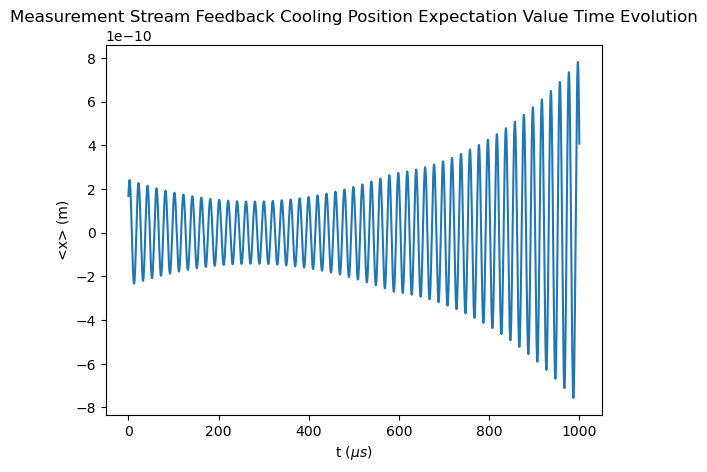

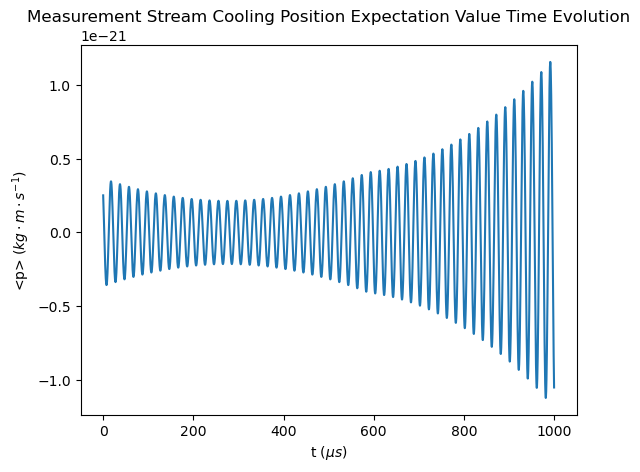

In [69]:
plt.figure()
plt.plot(t_real_arr*10**6, exp_x_real)
plt.xlabel("t ($\mu s$)")
plt.ylabel("<x> (m)")
plt.title("Measurement Stream Feedback Cooling Position Expectation Value Time Evolution")
plt.show()

plt.figure()
plt.plot(t_real_arr*10**6, exp_p_real)
plt.xlabel("t ($\mu s$)")
plt.ylabel("<p> ($kg \cdot m \cdot s^{-1}$)")
plt.title("Measurement Stream Cooling Position Expectation Value Time Evolution")
plt.show()

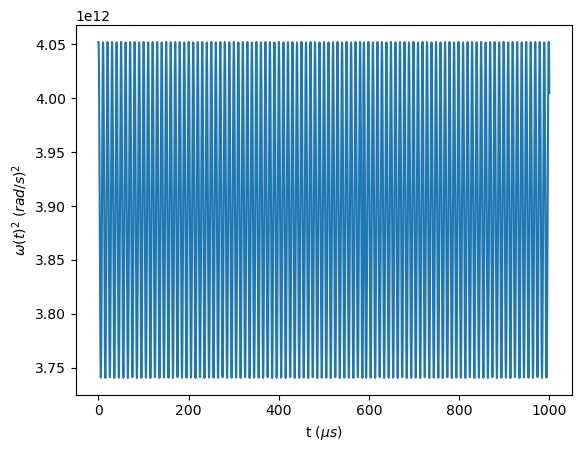

In [70]:
plt.figure()
plt.plot((t_real_arr)*10**6, np.array(w_sq_arr_real))
plt.xlabel("t ($\mu s$)")
plt.ylabel(r"$\omega(t)^2$ $(rad/s)^2$")
plt.show()

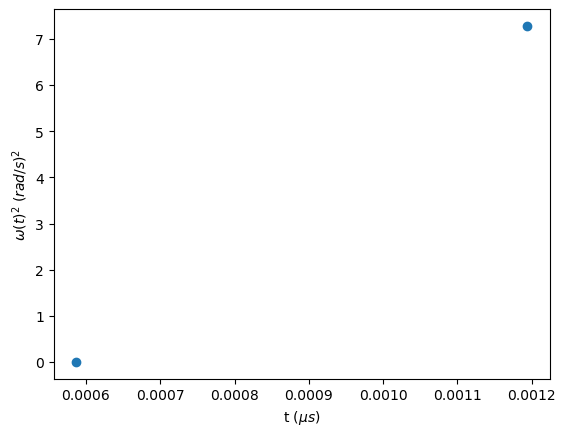

In [71]:
plt.figure()
plt.scatter(t_op_list, phi_p_list)
plt.xlabel("t ($\mu s$)")
plt.ylabel(r"$\omega(t)^2$ $(rad/s)^2$")
plt.show()